In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score

In [53]:
df = pd.read_csv('/kaggle/input/datasets/samvelgalstyan/loanpaytrain/train.csv')

In [54]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [56]:
df = df.drop('id',axis=1)

In [57]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [58]:
encoder.set_output(transform='pandas')

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [59]:
str_cols = df.select_dtypes('object').columns
num_cols = df.select_dtypes(['int','float']).columns
df_str = encoder.fit_transform(df[str_cols])
df_num = df[num_cols]

In [60]:
df_train = pd.concat([df_str,df_num],axis=1,)

In [61]:
X = df_train.drop('loan_paid_back',axis=1)
y = df_train['loan_paid_back']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [63]:
binary_cols = []
for i in X_train.columns:
    if X_train[i].nunique() <=2 and set(X_train[i]).issubset({0,1}):
        binary_cols.append(i)
num_cols = []
for i in X_train.columns:
    if i not in binary_cols:
        num_cols.append(i)

In [64]:
scaler = StandardScaler()
scaler.set_output(transform='pandas')
X_scale_train = scaler.fit_transform(X_train[num_cols])
X_scale_test = scaler.transform(X_test[num_cols])
X_noscale_train = X_train[binary_cols]
X_noscale_test = X_test[binary_cols]
X_main_train = pd.concat([X_scale_train,X_noscale_train], axis=1, ignore_index=False)
X_main_test = pd.concat([X_scale_test ,X_noscale_test], axis=1, ignore_index=False)

In [65]:
base_model = RandomForestClassifier()

In [66]:
params = {
    'n_estimators': [60,80,100,120],
    'max_depth': [4, 6, 8, 10, None],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', 'balanced_subsample'],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2']
}

In [67]:
model = RandomizedSearchCV(base_model, params, scoring='f1_macro', n_iter=10, cv=3, verbose=0, n_jobs=-1)

In [68]:
model.fit(X_main_train,y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [4, 6, 8, 10, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'n_estimators': [60, 80, 100, 120]},
                   scoring='f1_macro')

In [105]:
y_pred = model.predict_proba(X_main_test)[:,1]

In [110]:
fpr, tpr, threshold = roc_curve(y_test, y_pred)

In [111]:
youden = tpr - fpr
max_youden = np.argmax(youden)
best_threshold = threshold[max_youden]

(0.0, 1.1)

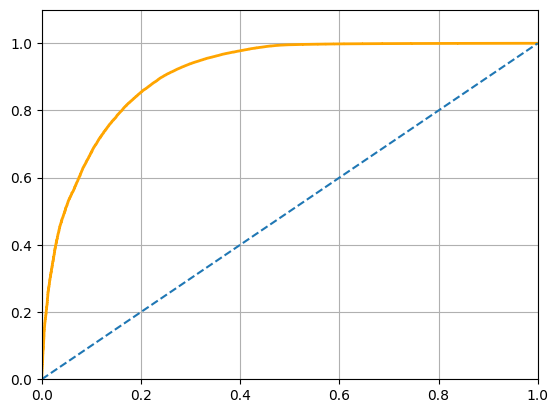

In [113]:
plt.plot(fpr, tpr, color='orange', linewidth=2)
plt.plot([0,1],[0,1], linestyle='dashed')
plt.grid(True)
plt.xlim(0,1)
plt.ylim(0,1.1)

In [118]:
y_pred = (y_pred > best_threshold).astype(int)

In [119]:
accuracy_score(y_test, y_pred)

0.8684416535492723

In [120]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.65      0.76      0.70     23997
         1.0       0.94      0.90      0.92     94802

    accuracy                           0.87    118799
   macro avg       0.79      0.83      0.81    118799
weighted avg       0.88      0.87      0.87    118799



In [121]:
confusion_matrix(y_test, y_pred)

array([[18292,  5705],
       [ 9924, 84878]])

<Axes: >

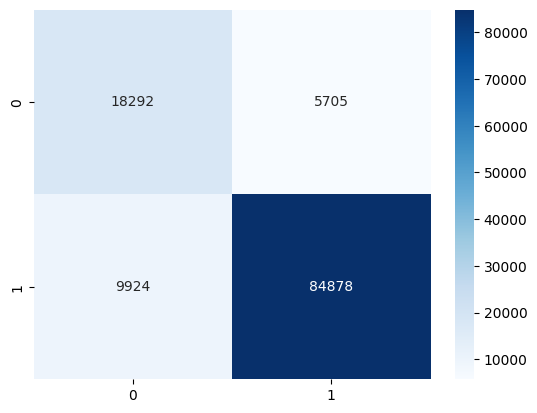

In [122]:
sns.heatmap(confusion_matrix(y_test, y_pred), cmap='Blues', annot=True, fmt='d')

In [123]:
import pickle

In [125]:
with open('LoanPayBack.pkl', 'wb') as f:
    pickle.dump(model.best_estimator_, f)